# Customer Churn EDA

This notebook explores the e-commerce churn dataset used in the production pipeline. It focuses on business questions, target imbalance, missingness, segment-level churn, and modelling risks such as leakage.

In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 15.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 18.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 15.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------- ----------------------------- 3.4/12.6 MB 18.3 MB/s eta 0:00:01
   -------------------- ------------------- 6.6/12.6 MB 16.1 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 15.8 MB/s  0:00

In [6]:
pip install seaborn pandas

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.9 MB 16.7 MB/s eta 0:00:01
   ---------------- ----------------------- 4.2/9.9 MB 12.6 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 16.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [pandas]
   ---------------------------------------- 0/2 [p

In [11]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/

In [13]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df = pd.read_excel(r"C:\Users\e16013172\AICC_Preparation\customer-churn-ai\data\raw\E Commerce Dataset.xlsx", sheet_name=1)
df.head()


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Dataset Shape and Data Quality

In [14]:
display(df.shape)
display(df.info())
display(df.isna().mean().sort_values(ascending=False).head(10))
display(df.duplicated().sum())

(5630, 20)

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

None

DaySinceLastOrder              0.054529
OrderAmountHikeFromlastYear    0.047069
Tenure                         0.046892
OrderCount                     0.045826
CouponUsed                     0.045471
HourSpendOnApp                 0.045293
WarehouseToHome                0.044583
CustomerID                     0.000000
PreferredLoginDevice           0.000000
Churn                          0.000000
dtype: float64

np.int64(0)

## Target Distribution

Churn
0    0.831616
1    0.168384
Name: share, dtype: float64

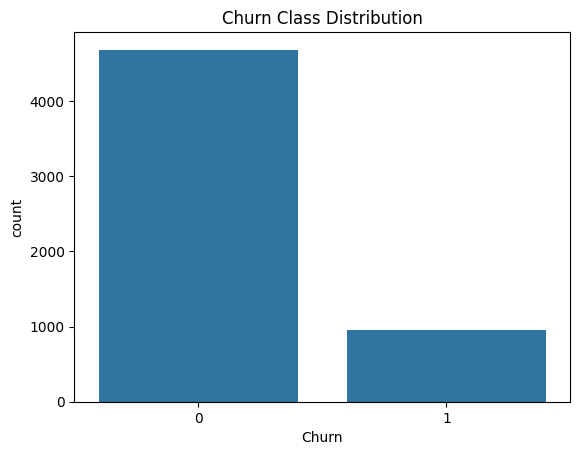

In [17]:
target_rate = df['Churn'].value_counts(normalize=True).rename('share')
display(target_rate)
sns.countplot(data=df, x='Churn')
plt.title('Churn Class Distribution')
plt.show()

## Segment-Level Churn Signals

In [19]:
segment_cols = ['complain', 'satisfaction_score', 'city_tier', 'preferred_payment_mode', 'marital_status']
for col in segment_cols:
    if col in df.columns:
        display(df.groupby(col)['Churn'].agg(['mean', 'count']).sort_values('mean', ascending=False))

## Numeric Relationships

Churn                          1.000000
Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
CustomerID                    -0.019083
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
Name: Churn, dtype: float64

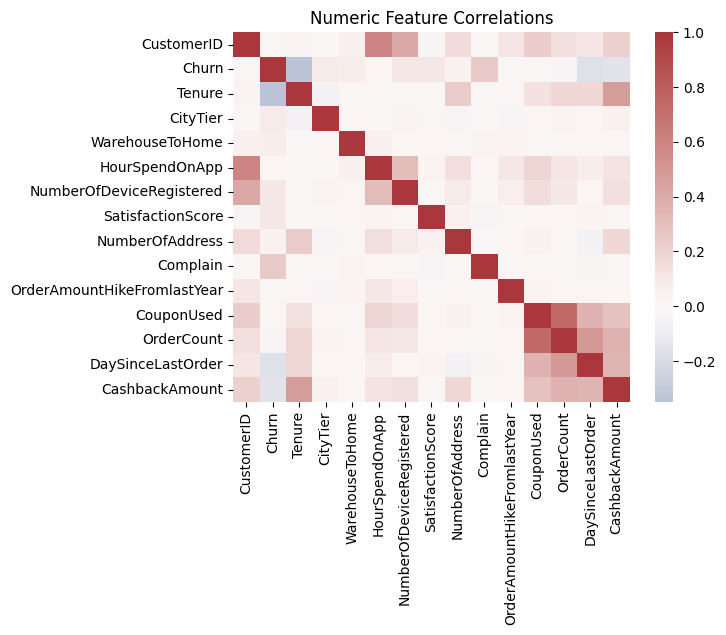

In [21]:
numeric = df.select_dtypes(include='number')
corr = numeric.corr(numeric_only=True)['Churn'].sort_values(key=abs, ascending=False)
display(corr)
sns.heatmap(numeric.corr(numeric_only=True), cmap='vlag', center=0)
plt.title('Numeric Feature Correlations')
plt.show()

<Axes: xlabel='Churn', ylabel='SatisfactionScore'>

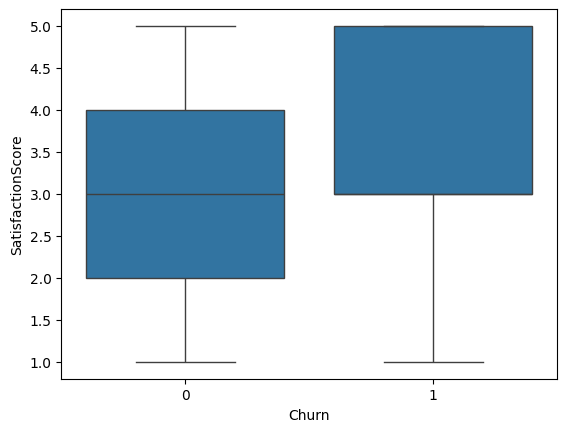

In [22]:
sns.boxplot(x="Churn", y="SatisfactionScore", data=df)

In [23]:
df["SatisfactionScore"] = 6 - df["SatisfactionScore"]

<Axes: xlabel='Churn', ylabel='SatisfactionScore'>

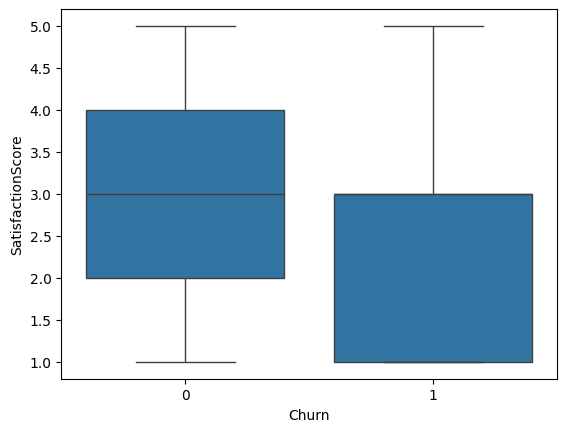

In [24]:
sns.boxplot(x="Churn", y="SatisfactionScore", data=df)

## EDA Notes for Stakeholders

- 16% of the customers in the dataset have been Churned, Churn is a minority event, so accuracy is not the decision metric.
- Complaint history, tenure, satisfaction, Cashbackamount and engagement(DaySincelastOrder) are expected drivers.
- These patterns are predictive associations, not proof of causality.
- Retention strategy should combine model scores with campaign cost and customer lifetime value.